# DPT Bone Marrow — Exploratory Notebook

This notebook:
1. Loads and preprocesses the Setty et al. 2019 bone marrow dataset
2. Plots cells coloured by cluster in UMAP and tSNE space
3. Explains and visualises root cell selection
4. Runs standard DPT (Diffusion Pseudotime) and plots pseudotime

In [11]:
import sys
import os
from pathlib import Path

NOTEBOOK_DIR = Path(os.getcwd())
TRAVELER_ROOT = NOTEBOOK_DIR.parents[1]
sys.path.insert(0, str(TRAVELER_ROOT))

DATA_FILE = TRAVELER_ROOT / 'data' / 'setty_bone_marrow.h5ad'

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=100, frameon=False)

## 1. Load and preprocess

Diffusion components are computed fresh and used for root cell selection. UMAP is recomputed as the visualisation and alignment target.

In [12]:
adata = sc.read(str(DATA_FILE))
print(adata)
print('\nObs columns:', adata.obs.columns.tolist())
print('Obsm keys:  ', list(adata.obsm.keys()))

AnnData object with n_obs × n_vars = 5780 × 27876
    obs: 'clusters', 'palantir_pseudotime', 'palantir_diff_potential'
    var: 'palantir'
    uns: 'clusters_colors', 'palantir_branch_probs_cell_types'
    obsm: 'MAGIC_imputed_data', 'X_tsne', 'palantir_branch_probs'
    layers: 'spliced', 'unspliced'

Obs columns: ['clusters', 'palantir_pseudotime', 'palantir_diff_potential']
Obsm keys:   ['MAGIC_imputed_data', 'X_tsne', 'palantir_branch_probs']


In [14]:
sc.pp.filter_genes(adata, min_counts=20)
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata)

sc.tl.pca(adata, random_state=42)
sc.pp.neighbors(adata, n_neighbors=50, n_pcs=10, random_state=42)
sc.tl.diffmap(adata, n_comps=10)
sc.tl.umap(adata, random_state=42)

print('Preprocessing done.')
print(adata)

/Users/Abhi/Desktop/TraVeLer/venv/lib/python3.9/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding


Preprocessing done.
AnnData object with n_obs × n_vars = 5780 × 11253
    obs: 'clusters', 'palantir_pseudotime', 'palantir_diff_potential'
    var: 'palantir', 'n_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'clusters_colors', 'palantir_branch_probs_cell_types', 'log1p', 'hvg', 'pca', 'neighbors', 'diffmap_evals', 'umap'
    obsm: 'MAGIC_imputed_data', 'X_tsne', 'palantir_branch_probs', 'X_pca', 'X_diffmap', 'X_umap'
    varm: 'PCs'
    layers: 'spliced', 'unspliced'
    obsp: 'distances', 'connectivities'


In [20]:
n = int(1 * adata.n_obs)
np.random.seed(42)
idx = np.random.choice(adata.n_obs, n, replace=False)
adata = adata[idx, :].copy()

sc.pp.filter_genes(adata, min_counts=20)
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata)

sc.tl.pca(adata, random_state=42)
sc.pp.neighbors(adata, n_neighbors=50, n_pcs=10, random_state=42)
sc.tl.diffmap(adata, n_comps=10)
sc.tl.umap(adata, random_state=42)

print('Preprocessing done.')
print(adata)

/Users/Abhi/Desktop/TraVeLer/venv/lib/python3.9/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding


Preprocessing done.
AnnData object with n_obs × n_vars = 5780 × 10787
    obs: 'clusters', 'palantir_pseudotime', 'palantir_diff_potential'
    var: 'palantir', 'n_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'clusters_colors', 'palantir_branch_probs_cell_types', 'log1p', 'hvg', 'pca', 'neighbors', 'diffmap_evals', 'umap'
    obsm: 'MAGIC_imputed_data', 'X_tsne', 'palantir_branch_probs', 'X_pca', 'X_diffmap', 'X_umap'
    varm: 'PCs'
    layers: 'spliced', 'unspliced'
    obsp: 'distances', 'connectivities'


## 2. Cells coloured by cluster

The Setty bone marrow dataset contains haematopoietic progenitor cell populations. Cell type annotations (if present) are in `adata.obs`.

In [21]:
# Identify a suitable cluster/celltype column
candidate_cols = [c for c in adata.obs.columns
                  if any(k in c.lower() for k in ['cluster', 'cell', 'type', 'label', 'anno'])]
print('Candidate annotation columns:', candidate_cols)
color_col = candidate_cols[0] if candidate_cols else None
print('Using:', color_col)

Candidate annotation columns: ['clusters']
Using: clusters


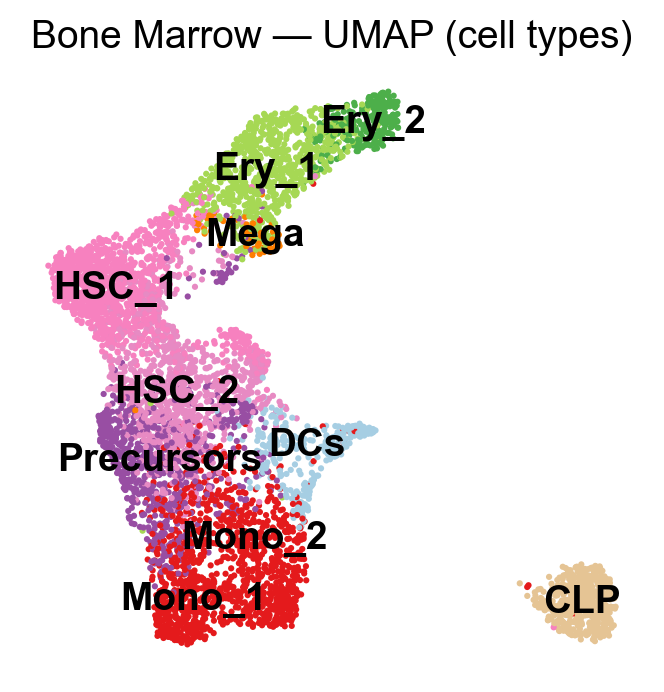

In [22]:
# UMAP coloured by cell type / cluster
if color_col:
    sc.pl.umap(adata, color=color_col, legend_loc='on data',
               title='Bone Marrow — UMAP (cell types)', frameon=False, size=20)
else:
    umap = adata.obsm['X_umap']
    plt.figure(figsize=(7, 5))
    plt.scatter(umap[:, 0], umap[:, 1], s=4, c='steelblue', linewidths=0)
    plt.title('Bone Marrow — UMAP')
    plt.xlabel('UMAP 1'); plt.ylabel('UMAP 2')
    plt.tight_layout(); plt.show()

## 3. Root cell selection

We select the root cell from **tSNE space** using the following logic:

1. Take cells in the **right half** of tSNE x (i.e. `x > mean(x)`)
2. Within those, take the **upper half** (i.e. `y > mean(y)` of all cells)
3. From the resulting upper-right quadrant, select the cell with the **highest tSNE y**

**Why?**  
In the Setty bone marrow tSNE, haematopoietic stem cells (HSCs) — the most primitive progenitors — cluster in the upper-right region. This quadrant-based heuristic reliably lands in the HSC population without requiring manual annotation matching.

## 3. Root cell selection

Root cell = **argmin of diffusion component DC4** (`X_diffmap[:, 3]`).

**Why?**  
In the Setty bone marrow diffusion map, DC4 captures the HSC-to-progenitor axis. The cell with the minimum DC4 value sits at the most primitive end of this axis (haematopoietic stem cells), making it a stable, embedding-agnostic anchor for pseudotime.

In [23]:
dc = adata.obsm['X_diffmap']
root = int(dc[:, 3].argmin())

print(f'Root cell index : {root}')
print(f'DC4 value       : {dc[root, 3]:.4f}')
if color_col:
    print(f'Cell type label : {adata.obs[color_col].iloc[root]}')

Root cell index : 4258
DC4 value       : -0.0261
Cell type label : HSC_1


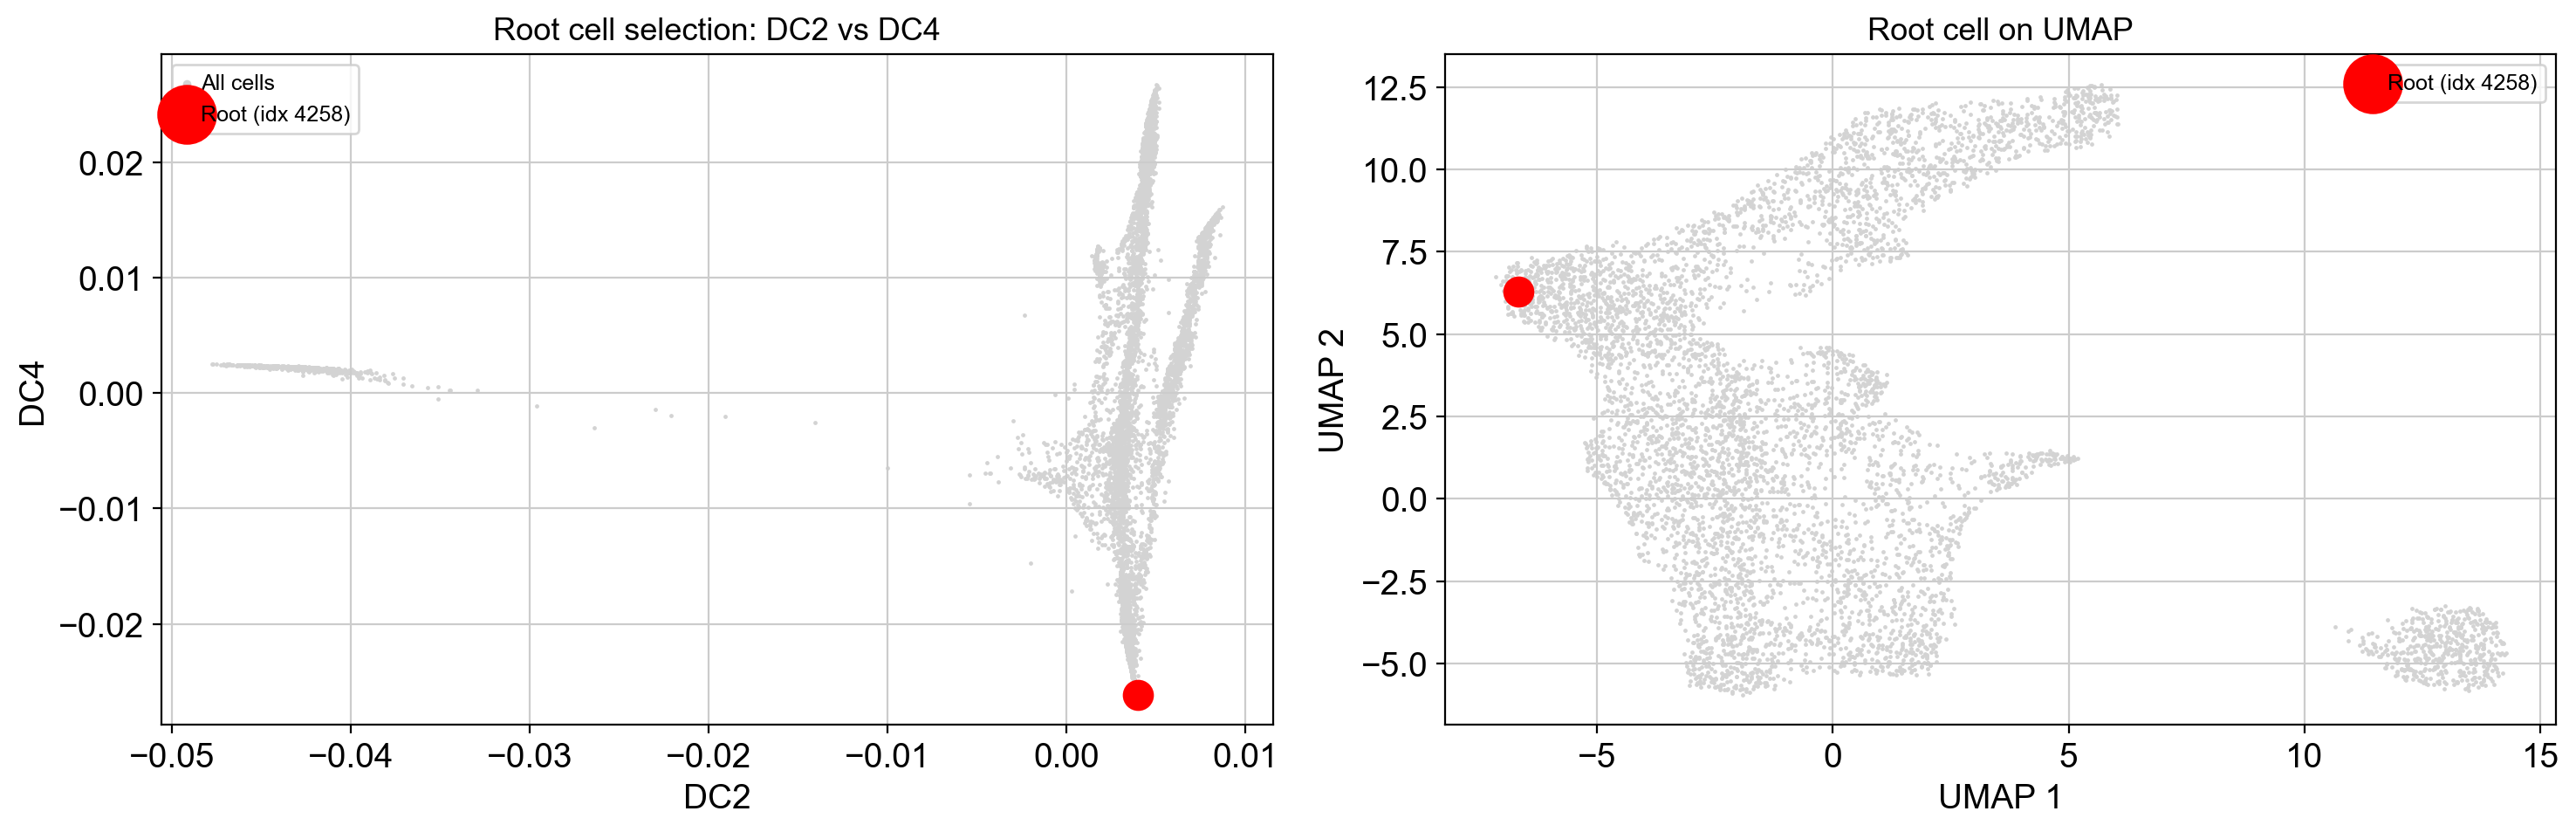

In [24]:
umap = adata.obsm['X_umap']
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# DC2 vs DC4 — show root selection axis
axes[0].scatter(dc[:, 1], dc[:, 3], s=3, c='lightgrey', linewidths=0, label='All cells')
axes[0].scatter(dc[root, 1], dc[root, 3], s=140, c='red', zorder=6, label=f'Root (idx {root})')
axes[0].set_title('Root cell selection: DC2 vs DC4', fontsize=13)
axes[0].set_xlabel('DC2'); axes[0].set_ylabel('DC4')
axes[0].legend(fontsize=9, markerscale=2)

# UMAP — show root
axes[1].scatter(umap[:, 0], umap[:, 1], s=3, c='lightgrey', linewidths=0)
axes[1].scatter(umap[root, 0], umap[root, 1], s=140, c='red', zorder=6, label=f'Root (idx {root})')
axes[1].set_title('Root cell on UMAP', fontsize=13)
axes[1].set_xlabel('UMAP 1'); axes[1].set_ylabel('UMAP 2')
axes[1].legend(fontsize=9, markerscale=2)

plt.tight_layout()
plt.show()

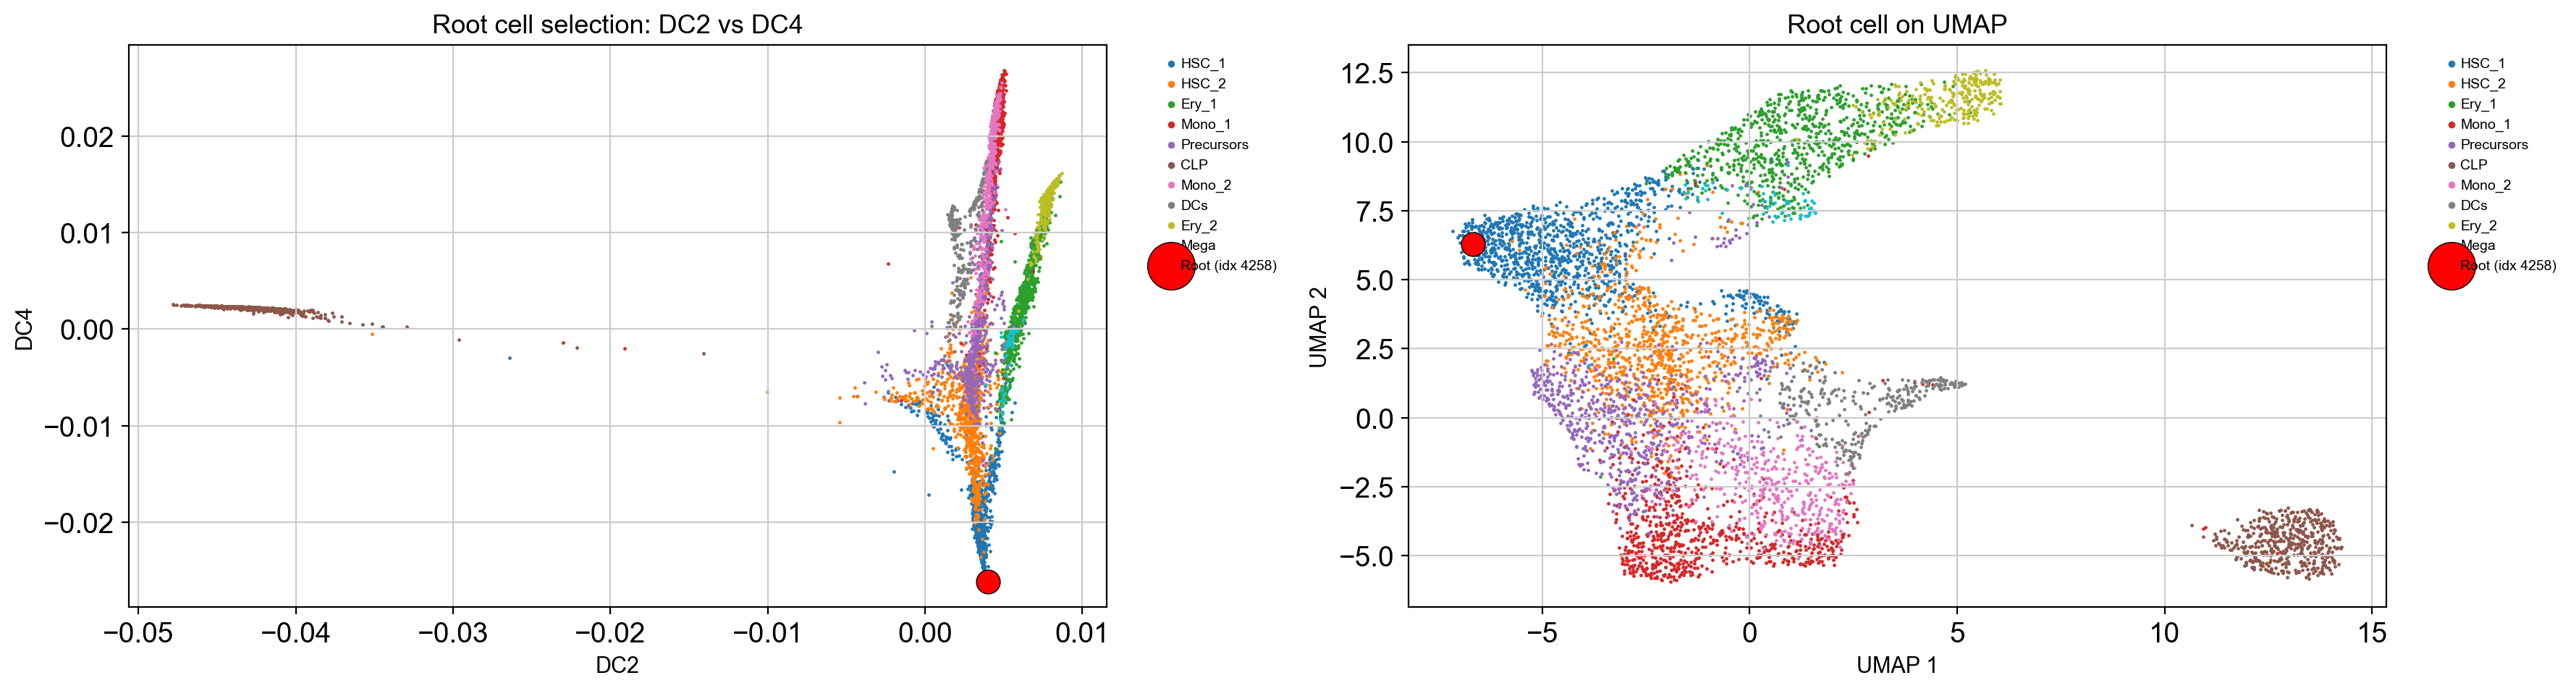

In [25]:
umap = adata.obsm['X_umap']

# Build colour map from cell type annotation
if color_col:
    categories = adata.obs[color_col].astype('category').cat.categories
    cmap_cat = plt.cm.tab20
    color_map = {cat: cmap_cat(i / len(categories)) for i, cat in enumerate(categories)}
else:
    color_map = None

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# --- DC2 vs DC4 --- coloured by cell type, root highlighted
if color_col:
    for cat in categories:
        mask = np.array(adata.obs[color_col] == cat)
        axes[0].scatter(dc[mask, 1], dc[mask, 3], s=3, linewidths=0,
                        color=color_map[cat], label=cat)
else:
    axes[0].scatter(dc[:, 1], dc[:, 3], s=3, c='lightgrey', linewidths=0, label='All cells')

axes[0].scatter(dc[root, 1], dc[root, 3], s=140, c='red', zorder=6,
                edgecolors='black', linewidths=0.5, label=f'Root (idx {root})')
axes[0].set_title('Root cell selection: DC2 vs DC4', fontsize=13)
axes[0].set_xlabel('DC2', fontsize=11)
axes[0].set_ylabel('DC4', fontsize=11)
axes[0].legend(fontsize=7, markerscale=2,
               bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)

# --- UMAP --- coloured by cell type, root highlighted
if color_col:
    for cat in categories:
        mask = np.array(adata.obs[color_col] == cat)
        axes[1].scatter(umap[mask, 0], umap[mask, 1], s=3, linewidths=0,
                        color=color_map[cat], label=cat)
else:
    axes[1].scatter(umap[:, 0], umap[:, 1], s=3, c='lightgrey', linewidths=0)

axes[1].scatter(umap[root, 0], umap[root, 1], s=140, c='red', zorder=6,
                edgecolors='black', linewidths=0.5, label=f'Root (idx {root})')
axes[1].set_title('Root cell on UMAP', fontsize=13)
axes[1].set_xlabel('UMAP 1', fontsize=11)
axes[1].set_ylabel('UMAP 2', fontsize=11)
axes[1].legend(fontsize=7, markerscale=2,
               bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)

plt.tight_layout()
plt.show()

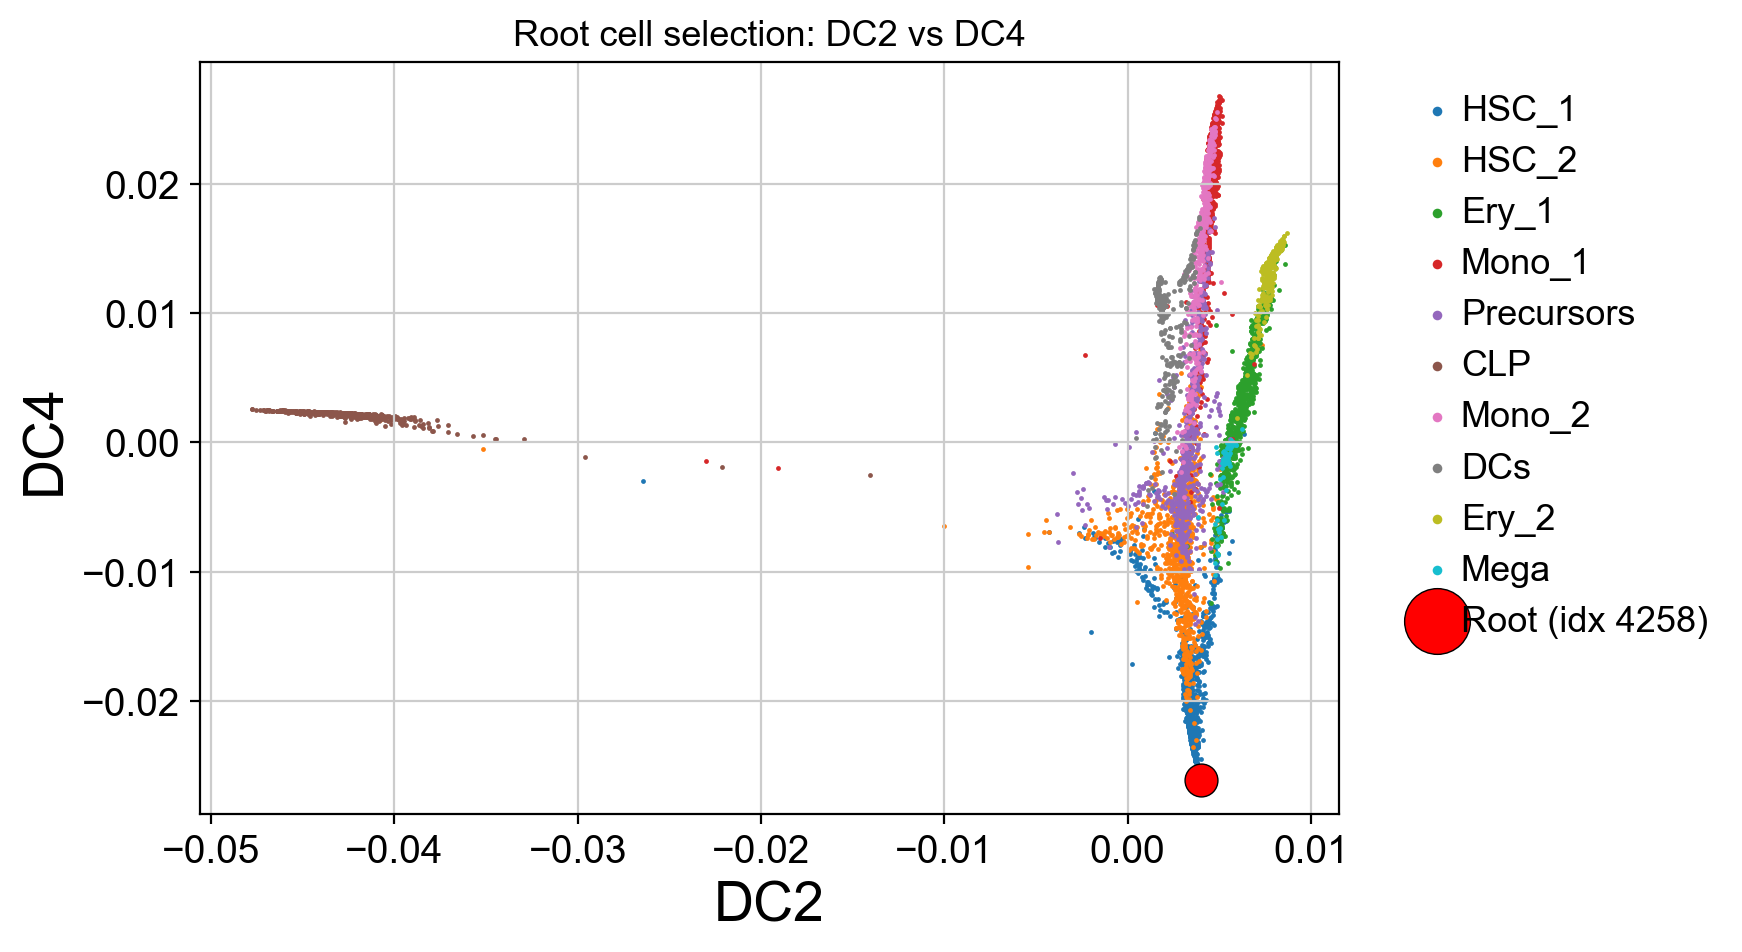

In [28]:
fig, ax = plt.subplots(figsize=(9, 5))

# DC2 vs DC4 — coloured by cell type, root highlighted
if color_col:
    for cat in categories:
        mask = np.array(adata.obs[color_col] == cat)
        ax.scatter(dc[mask, 1], dc[mask, 3], s=3, linewidths=0,
                   color=color_map[cat], label=cat)
else:
    ax.scatter(dc[:, 1], dc[:, 3], s=3, c='lightgrey', linewidths=0, label='All cells')

ax.scatter(dc[root, 1], dc[root, 3], s=140, c='red', zorder=6,
           edgecolors='black', linewidths=0.5, label=f'Root (idx {root})')
ax.set_title('Root cell selection: DC2 vs DC4', fontsize=13)
ax.set_xlabel('DC2', fontsize=20)
ax.set_ylabel('DC4', fontsize=20)
ax.legend(fontsize=13, markerscale=2,
          bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)

plt.tight_layout()
plt.show()

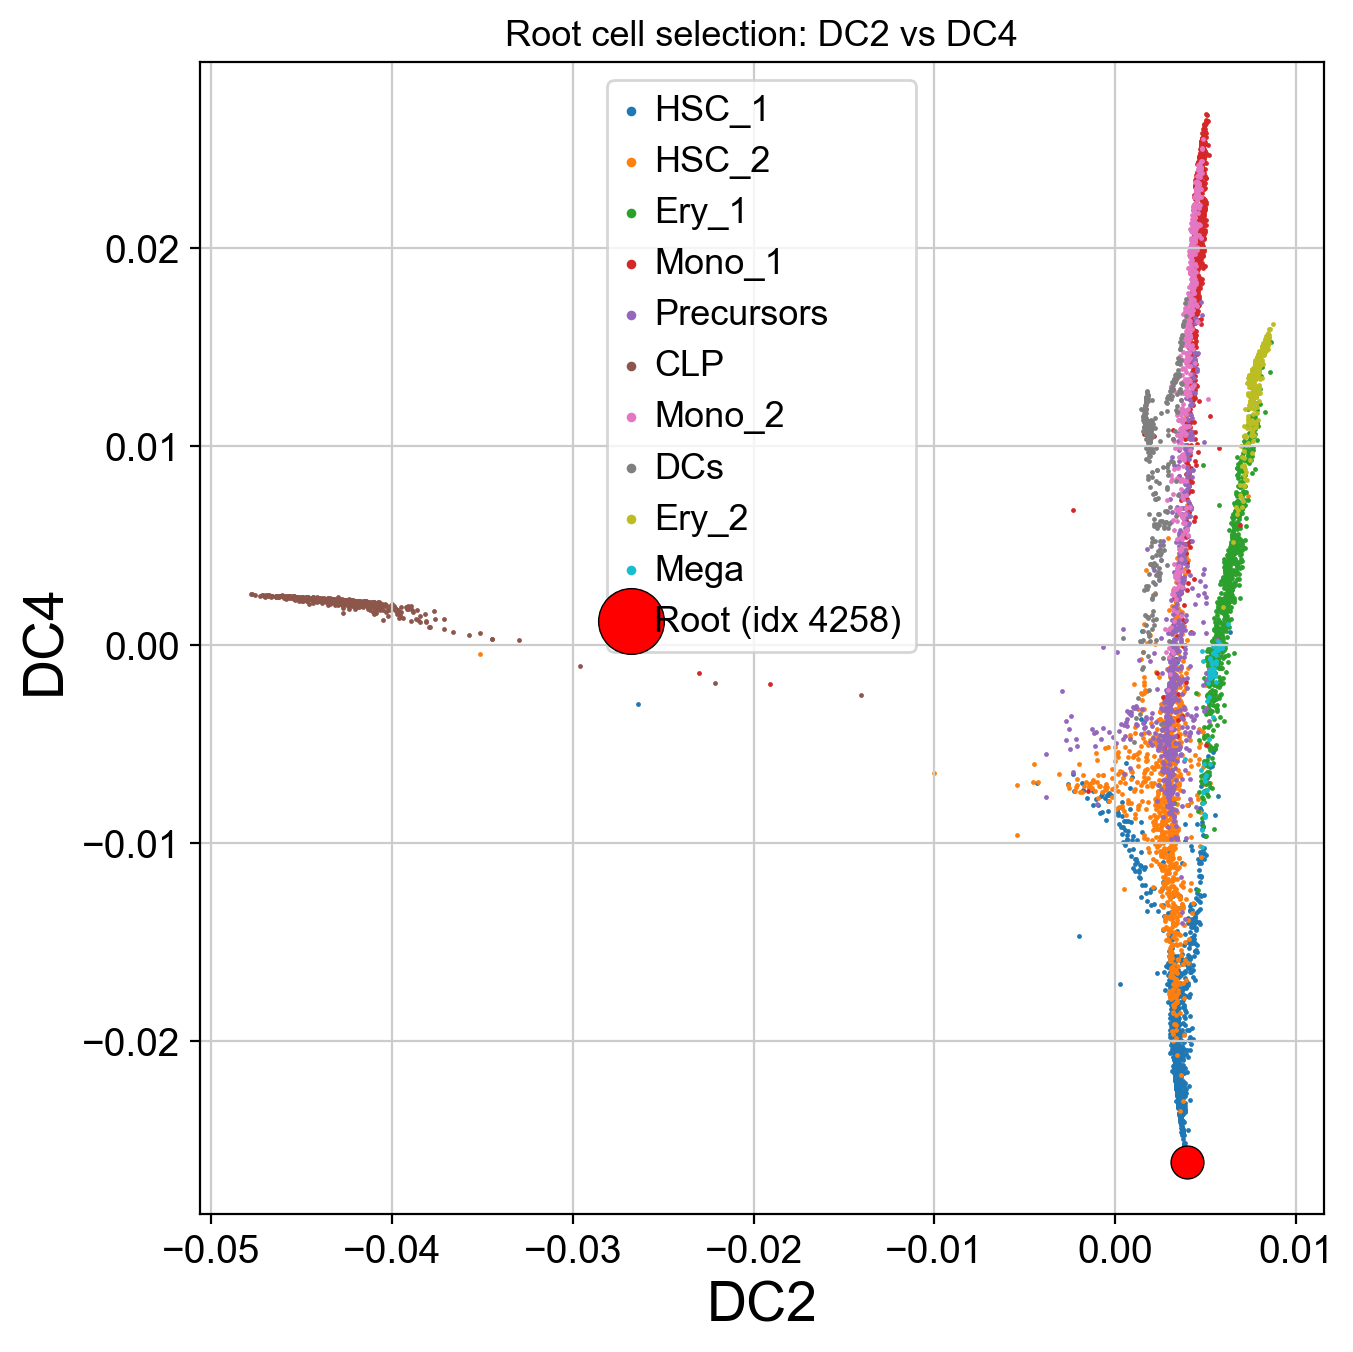

In [36]:
fig, ax = plt.subplots(figsize=(7, 7))

# DC2 vs DC4 — coloured by cell type, root highlighted
if color_col:
    for cat in categories:
        mask = np.array(adata.obs[color_col] == cat)
        ax.scatter(dc[mask, 1], dc[mask, 3], s=3, linewidths=0,
                   color=color_map[cat], label=cat)
else:
    ax.scatter(dc[:, 1], dc[:, 3], s=3, c='lightgrey', linewidths=0, label='All cells')

ax.scatter(dc[root, 1], dc[root, 3], s=140, c='red', zorder=6,
           edgecolors='black', linewidths=0.5, label=f'Root (idx {root})')
ax.set_title('Root cell selection: DC2 vs DC4', fontsize=13)
ax.set_xlabel('DC2', fontsize=20)
ax.set_ylabel('DC4', fontsize=20)
ax.legend(fontsize=13, markerscale=2,
          loc='best', frameon=True)

plt.tight_layout()
plt.show()

In [8]:
adata.uns['iroot'] = root
sc.tl.dpt(adata)
print('DPT range:', adata.obs['dpt_pseudotime'].min(), '–', adata.obs['dpt_pseudotime'].max())

DPT range: 0.0 – 1.0


NameError: name 'tsne' is not defined

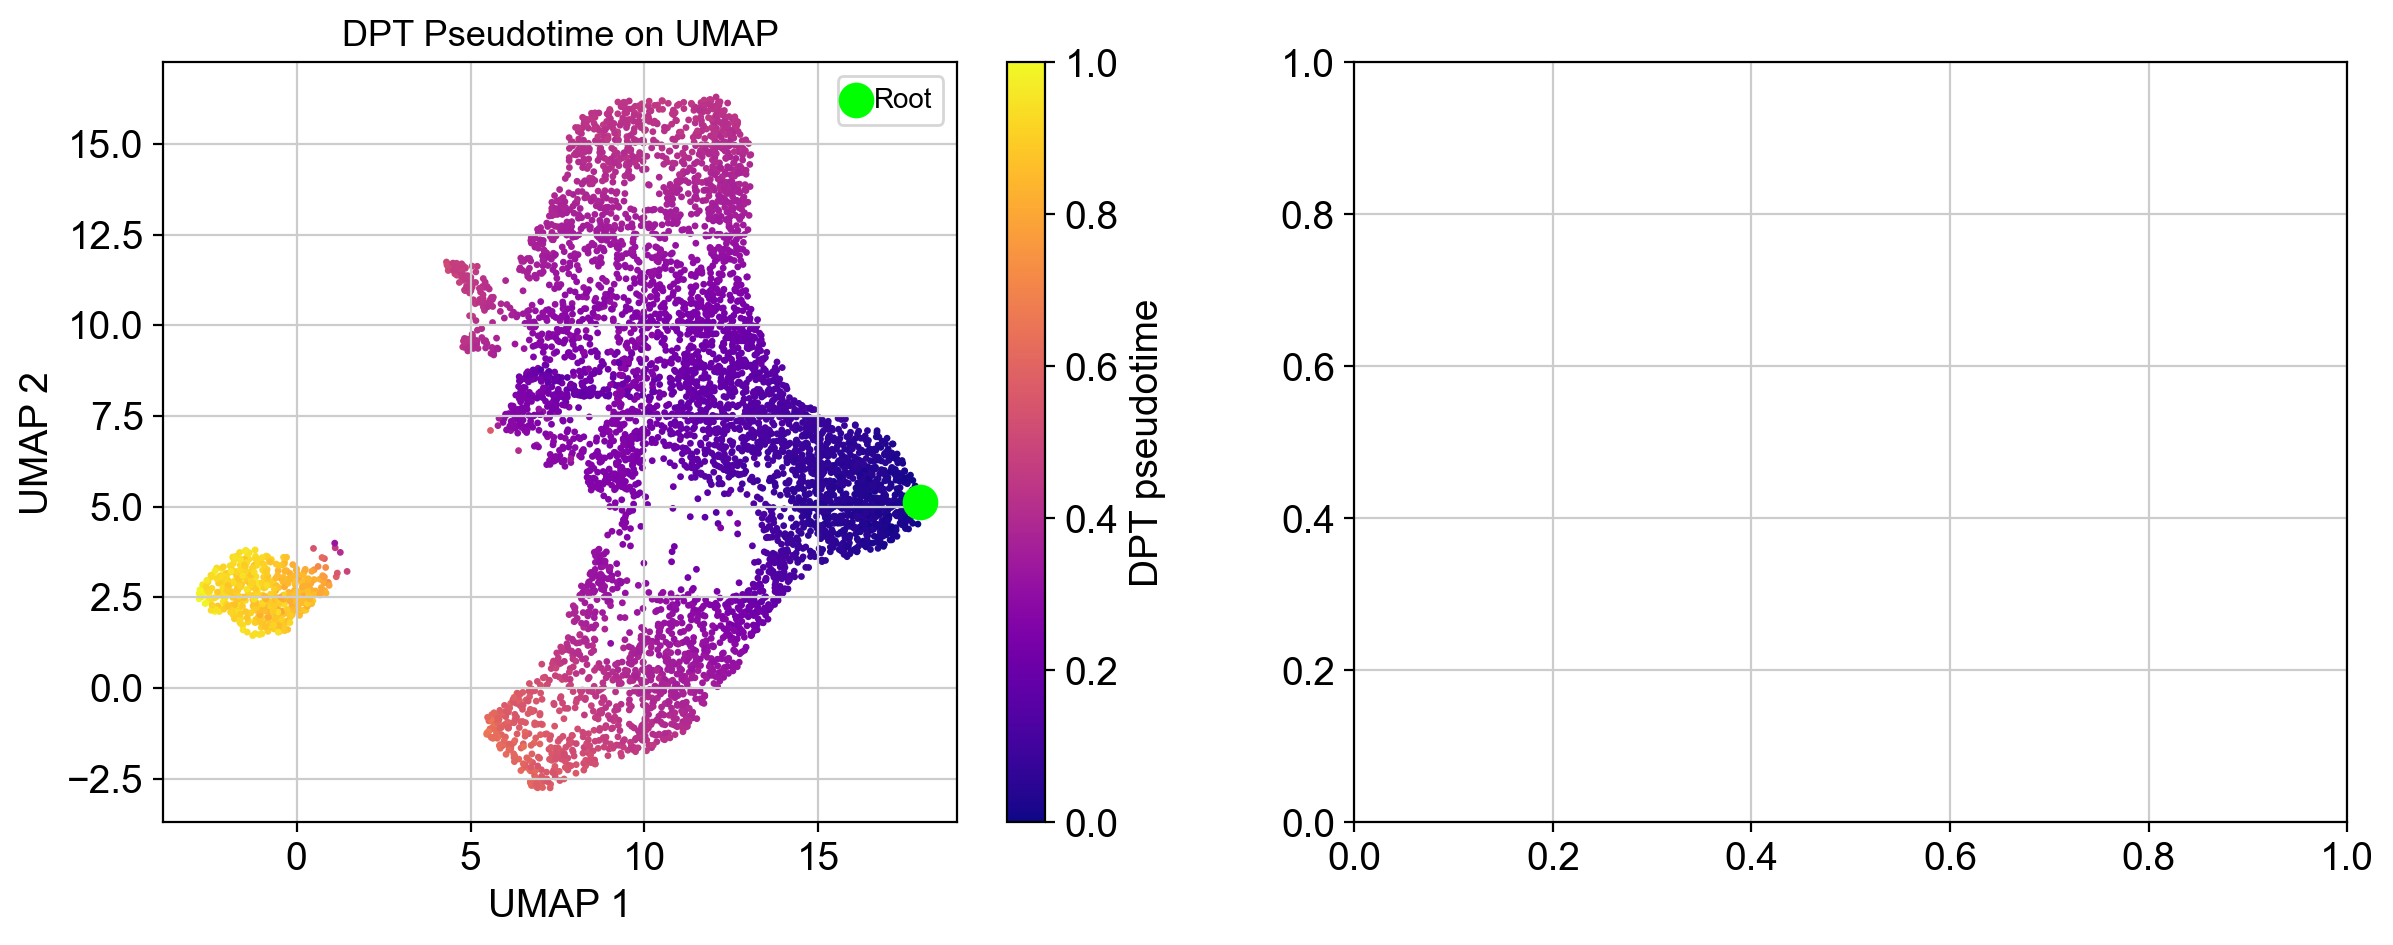

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pt = adata.obs['dpt_pseudotime'].values

sc0 = axes[0].scatter(umap[:, 0], umap[:, 1], c=pt, cmap='plasma', s=6, linewidths=0)
axes[0].scatter(umap[root, 0], umap[root, 1], s=140, c='lime', zorder=5, label='Root')
plt.colorbar(sc0, ax=axes[0], label='DPT pseudotime')
axes[0].set_title('DPT Pseudotime on UMAP', fontsize=13)
axes[0].set_xlabel('UMAP 1'); axes[0].set_ylabel('UMAP 2')
axes[0].legend(fontsize=10)

sc1 = axes[1].scatter(tsne[:, 0], tsne[:, 1], c=pt, cmap='plasma', s=6, linewidths=0)
axes[1].scatter(tsne[root, 0], tsne[root, 1], s=140, c='lime', zorder=5, label='Root')
plt.colorbar(sc1, ax=axes[1], label='DPT pseudotime')
axes[1].set_title('DPT Pseudotime on tSNE', fontsize=13)
axes[1].set_xlabel('tSNE 1'); axes[1].set_ylabel('tSNE 2')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

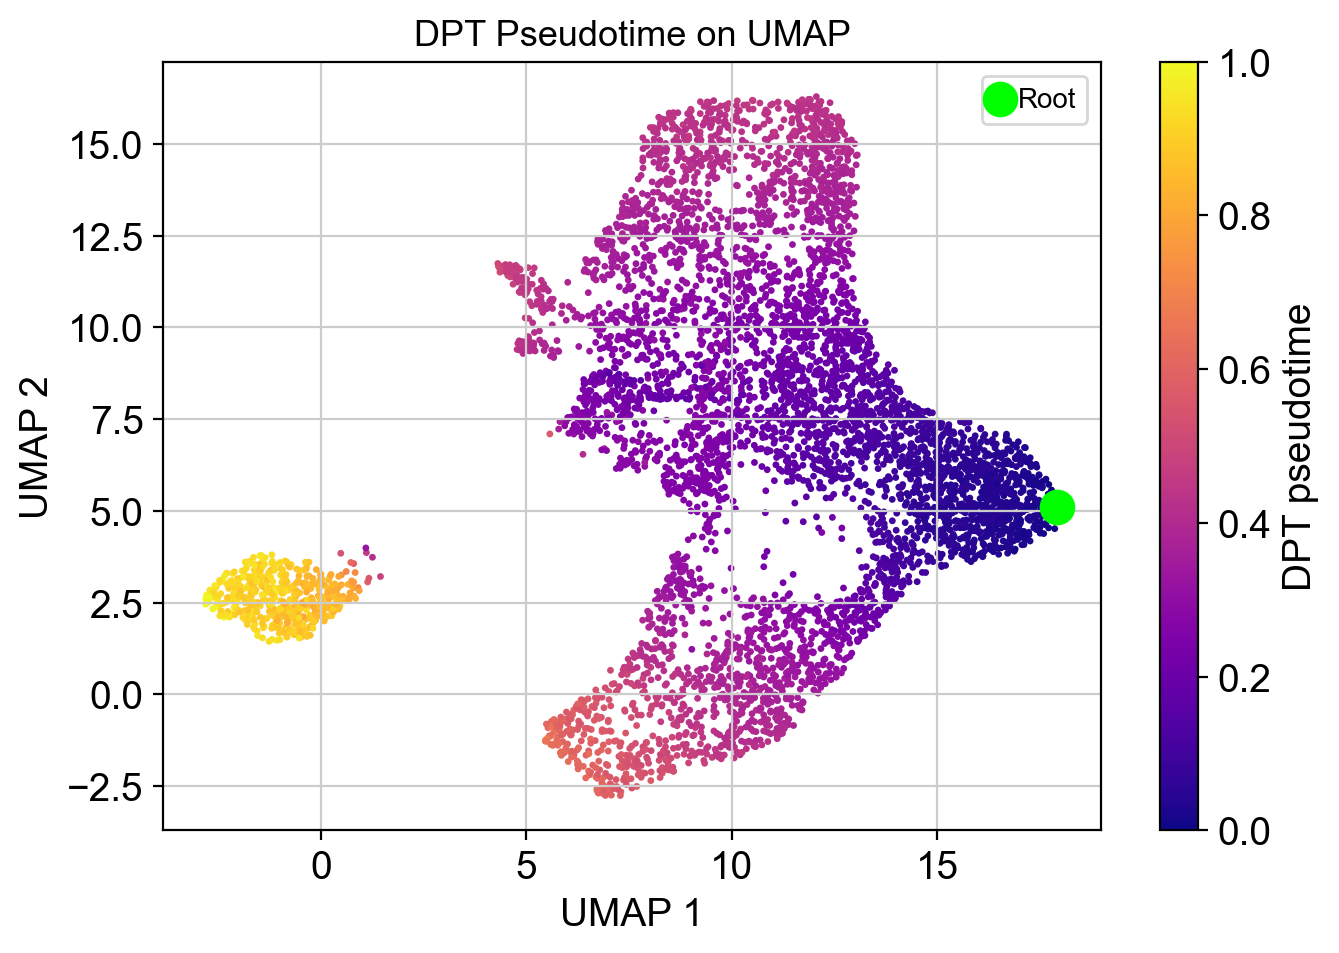

In [10]:
pt = adata.obs['dpt_pseudotime'].values

fig, ax = plt.subplots(figsize=(7, 5))
sc0 = ax.scatter(umap[:, 0], umap[:, 1], c=pt, cmap='plasma', s=6, linewidths=0)
ax.scatter(umap[root, 0], umap[root, 1], s=140, c='lime', zorder=5, label='Root')
plt.colorbar(sc0, ax=ax, label='DPT pseudotime')
ax.set_title('DPT Pseudotime on UMAP', fontsize=13)
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()